In [1]:
# Verificar qué hay en la carpeta models
import os
print(os.listdir("../models"))

['.gitignore', '.ipynb_checkpoints', '09_models.ipynb', 'baseline_decision_tree.pkl', 'baseline_knn.pkl', 'baseline_logistic_regression.pkl', 'baseline_random_forest.pkl', 'baseline_svm.pkl', 'preprocessing_pipeline.pkl', 'preprocessing_pipeline.pkl.dvc']


In [1]:
import joblib
import os

print("🔍 Cargando modelo...")
modelo = joblib.load("../models/baseline_logistic_regression.pkl")
print("✅ ÉXITO: Modelo cargado")
print(f"   Tipo: {type(modelo)}")

🔍 Cargando modelo...
✅ ÉXITO: Modelo cargado
   Tipo: <class 'imblearn.pipeline.Pipeline'>


C:\Users\winx_\anaconda3\envs\proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\winx_\anaconda3\envs\proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\winx_\anaconda3\envs\proyecto\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.7.2 when us

✅ Librerías cargadas

📂 Cargando datos raw...
✅ Datos raw: (10000, 18)
🎯 Target: Revenue

🛠️ Preprocesando datos...
✅ X_scaled shape: (10000, 14)
📊 Train: 8000, Test: 2000

🔍 Modelo: Logistic Regression

📊 MÉTRICAS:
   Accuracy:  0.8960
   Precision: 0.8030
   Recall:    0.3681
   F1-Score:  0.5048
   AUC-ROC:   0.8925

📊 CROSS-VALIDATION (5-fold):
   F1 scores: [0.51955307 0.47536232 0.48414986 0.58045977 0.49431818]
   Mean F1:   0.5108 ± 0.0379

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No Revenue       0.90      0.98      0.94      1712
     Revenue       0.80      0.37      0.50       288

    accuracy                           0.90      2000
   macro avg       0.85      0.68      0.72      2000
weighted avg       0.89      0.90      0.88      2000


📊 CONFUSION MATRIX:
   TN: 1686  FP: 26
   FN: 182  TP: 106

🔍 Modelo: Decision Tree

📊 MÉTRICAS:
   Accuracy:  0.8625
   Precision: 0.5225
   Recall:    0.5243
   F1-Score:  0.5234
   AUC-ROC: 

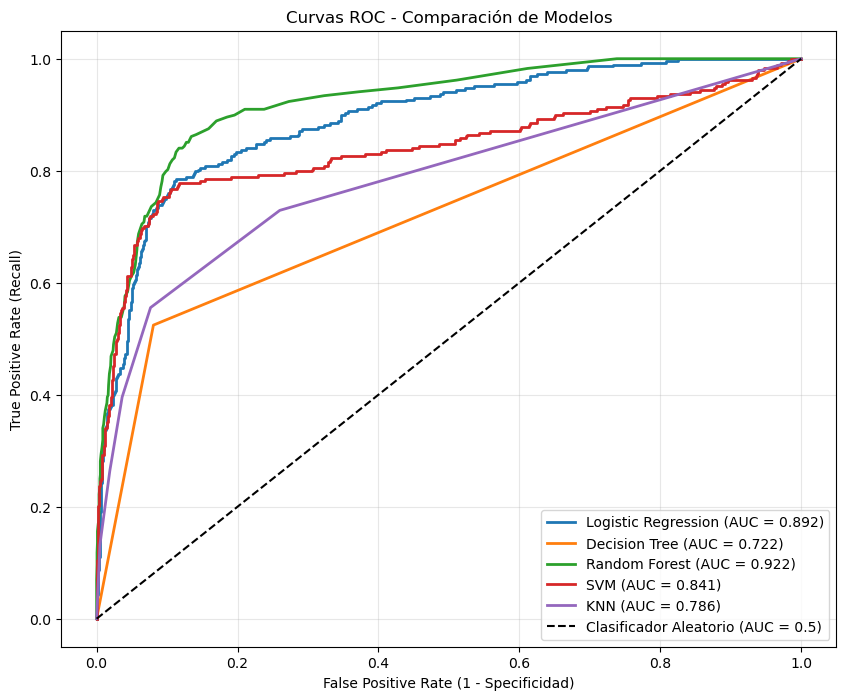

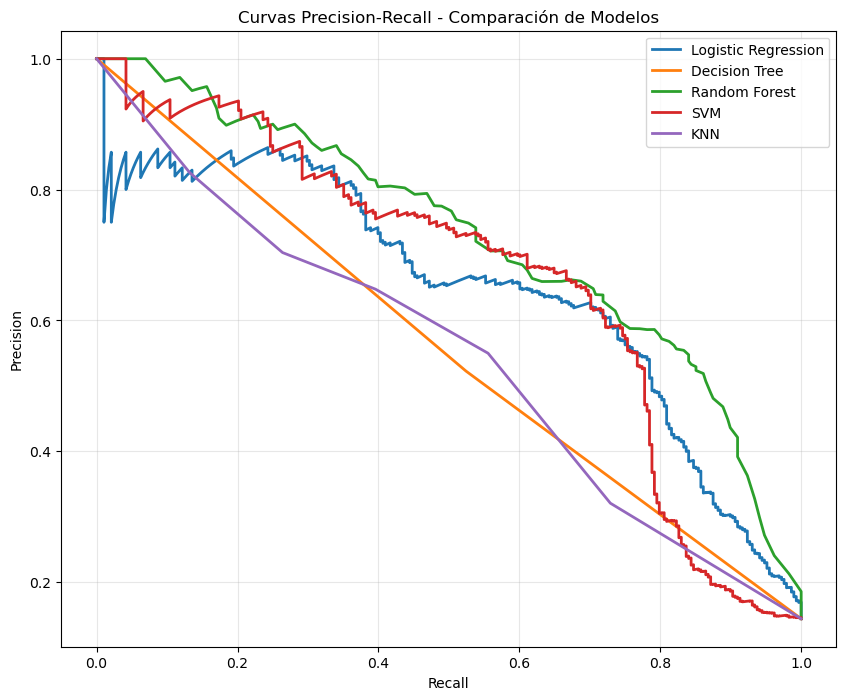

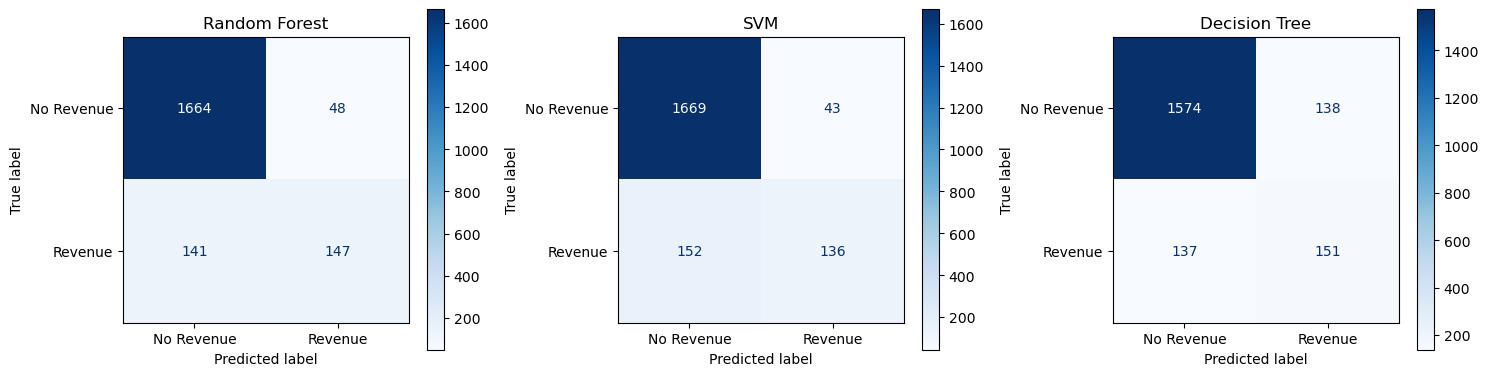

In [2]:
# ============================================
# PB-11 - VERSIÓN COMPLETA (con todos los requisitos)
# ============================================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Librerías cargadas")

# ============================================
# 1. CARGAR DATOS RAW
# ============================================
print("\n📂 Cargando datos raw...")
df_raw = pd.read_csv("../data/raw/dataset_pucp.csv", nrows=10000)
print(f"✅ Datos raw: {df_raw.shape}")

target = 'Revenue' if 'Revenue' in df_raw.columns else df_raw.columns[-1]
print(f"🎯 Target: {target}")

y = df_raw[target]
X_raw = df_raw.drop(columns=[target])

# ============================================
# 2. PREPROCESAMIENTO MANUAL
# ============================================
print("\n🛠️ Preprocesando datos...")
X = X_raw.select_dtypes(include=[np.number])

for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"✅ X_scaled shape: {X_scaled.shape}")

# ============================================
# 3. DIVIDIR DATOS
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"📊 Train: {len(X_train)}, Test: {len(X_test)}")

# ============================================
# 4. DEFINIR MODELOS
# ============================================
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier()
}

# ============================================
# 5. EVALUAR CADA MODELO (CON TODAS LAS MÉTRICAS)
# ============================================
resultados = []

for nombre, modelo in modelos.items():
    print(f"\n{'='*60}")
    print(f"🔍 Modelo: {nombre}")
    print(f"{'='*60}")
    
    # Entrenar
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    # Calcular probabilidades
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    # ========================================
    # MÉTRICAS BÁSICAS
    # ========================================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    print(f"\n📊 MÉTRICAS:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    if auc:
        print(f"   AUC-ROC:   {auc:.4f}")
    
    # ========================================
    # CROSS-VALIDATION (5-fold stratified)
    # ========================================
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1')
    print(f"\n📊 CROSS-VALIDATION (5-fold):")
    print(f"   F1 scores: {cv_scores}")
    print(f"   Mean F1:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # ========================================
    # CLASSIFICATION REPORT
    # ========================================
    print(f"\n📊 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=['No Revenue', 'Revenue']))
    
    # ========================================
    # CONFUSION MATRIX
    # ========================================
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n📊 CONFUSION MATRIX:")
    print(f"   TN: {cm[0,0]}  FP: {cm[0,1]}")
    print(f"   FN: {cm[1,0]}  TP: {cm[1,1]}")
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1_Score': round(f1, 4),
        'AUC_ROC': round(auc, 4) if auc else None,
        'CV_Mean': round(cv_scores.mean(), 4),
        'CV_Std': round(cv_scores.std(), 4)
    })

# ============================================
# 6. TABLA COMPARATIVA FINAL
# ============================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1_Score', ascending=False)

print("\n" + "="*80)
print("📈 TABLA COMPARATIVA DE MODELOS")
print("="*80)
print(df_resultados.to_string(index=False))

# ============================================
# 7. VISUALIZACIONES
# ============================================

# 7.1 Curvas ROC
plt.figure(figsize=(10, 8))
for nombre, modelo in modelos.items():
    if hasattr(modelo, "predict_proba"):
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificidad)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 7.2 Curvas Precision-Recall
plt.figure(figsize=(10, 8))
for nombre, modelo in modelos.items():
    if hasattr(modelo, "predict_proba"):
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(recall, precision, label=f'{nombre}', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall - Comparación de Modelos')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# 7.3 Matrices de confusión (para los 3 mejores modelos)
mejores = df_resultados.head(3)['Modelo'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, nombre in enumerate(mejores):
    modelo = modelos[nombre]
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Revenue', 'Revenue'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{nombre}')

plt.tight_layout()
plt.show()